# Notebook 1 — Dataset Creation

**Objective.** Turn many raw recording sessions into **one consolidated,
machine-learning-ready dataset** — fully automatically.

This notebook covers the *entire* path from raw session folders to the final
CSV. It first runs the **emotion-labelling pipeline**
(`02_emotion_labelling.ipynb`) on every session to (re)generate that
session's labelled windows, then collects and merges the non-overlapping
ML-grid export from each session.

The label produced by that pipeline is a **proxy label**, not ground truth —
there is no self-report to validate it against (see
`02_emotion_labelling.ipynb`, §4.0/§4.14). This notebook does not change
that; it only automates running the pipeline across every session and
merging the results.

### Complete workflow
1. **Scan** the input directory for all session folders.
2. **Run the emotion-labelling pipeline** for every session → produces
   `labelled_windows_ml.csv` (non-overlapping windows, one row each) inside
   each session folder.
3. **Verify** a labelled CSV was successfully created for each session.
4. **Load** all labelled CSVs.
5. **Merge** them into one consolidated dataset.
6. **Save** the combined dataset as a single CSV.

Each session folder is expected to contain at least the raw `events.jsonl`
(and `video.mp4` for the facial-expression side of the label) plus
`session_meta.json`:

```
sessions/
├── 2025-11-26_14-30_proband_01/
│   ├── events.jsonl
│   ├── session_meta.json
│   ├── video.mp4                        (required for the facial-expression side of the label)
│   ├── labelled_windows_ml.csv          ← (re)generated in step 2 — non-overlapping, this is what we collect
│   └── labelled_windows_overlapping.csv ← (re)generated in step 2 — overlapping, inspection only, not collected here
└── ...
```


## 1  Imports & Configuration

`SESSIONS_ROOT` holds all session sub-folders. `EMOTION_LABELLING_NB` is the
emotion-labelling pipeline notebook that is executed once per session.
`REGENERATE_LABELS` controls whether existing labelled CSVs are recomputed or
reused.


In [13]:
import json
import os
import re
import subprocess
import sys
from pathlib import Path

import pandas as pd

# ── Configuration ────────────────────────────────────────────────
SESSIONS_ROOT        = Path("../data/sessions")                          # all session sub-folders
EMOTION_LABELLING_NB = Path("./02_emotion_labelling.ipynb")        # the labelling pipeline itself
CSV_NAME              = "labelled_windows_ml.csv"                  # per-session output we collect - non-overlapping ML grid
OUTPUT_CSV            = Path("../data/datasets/consolidated_dataset.csv")         # final consolidated dataset

# If True, re-run the pipeline for every session even if a labelled CSV exists.
# If False, sessions that already have a labelled CSV are skipped (faster re-runs).
REGENERATE_LABELS = False

# Drop windows the pipeline could not classify (label == "excluded").
DROP_EXCLUDED = True

print(f"Sessions root          : {SESSIONS_ROOT.resolve()}")
print(f"Emotion-labelling nb   : {EMOTION_LABELLING_NB.resolve()}")
print(f"Collecting             : {CSV_NAME}")
print(f"Output                 : {OUTPUT_CSV.resolve()}")
print(f"Regenerate labels      : {REGENERATE_LABELS}")


Sessions root          : C:\Uni Koeln\COIN_Project\COIN2026_Team-1_Plant-Emotion-Detector\data\sessions
Emotion-labelling nb   : C:\Uni Koeln\COIN_Project\COIN2026_Team-1_Plant-Emotion-Detector\notebooks\02_emotion_labelling.ipynb
Output                 : C:\Uni Koeln\COIN_Project\COIN2026_Team-1_Plant-Emotion-Detector\data\datasets\consolidated_dataset.csv
Regenerate labels      : False


## 2  Step 1 — Scan for Session Folders

A session is any sub-folder of `SESSIONS_ROOT` that contains a
`session_meta.json` (written by the recording notebook). We discover them
automatically so new recordings are picked up just by dropping their folder in.


In [14]:
def scan_session_folders(root: Path) -> list[Path]:
    """Return every session folder under `root` that has a session_meta.json."""
    if not root.exists():
        raise FileNotFoundError(f"Sessions root not found: {root.resolve()}")
    folders = sorted(p.parent for p in root.glob("*/session_meta.json"))
    return folders


session_folders = scan_session_folders(SESSIONS_ROOT)
print(f"Found {len(session_folders)} session folder(s):\n")
for f in session_folders:
    has_csv = (f / CSV_NAME).exists()
    print(f"  {f.name:<34}  labelled_csv={'yes' if has_csv else 'no'}")

if not session_folders:
    raise RuntimeError(
        f"No session folders found under {SESSIONS_ROOT.resolve()}.\n"
        "Each session must contain a session_meta.json produced by the recorder."
    )


Found 15 session folder(s):

  2026-07-06_16-11_proband_01         labelled_csv=yes
  2026-07-06_16-25_proband_02         labelled_csv=yes
  2026-07-06_16-39_proband_03         labelled_csv=yes
  2026-07-06_16-54_proband_04         labelled_csv=yes
  2026-07-06_17-20_proband_05         labelled_csv=yes
  2026-07-06_17-33_proband_06         labelled_csv=yes
  2026-07-06_17-49_proband_07         labelled_csv=yes
  2026-07-06_18-03_proband_08         labelled_csv=yes
  2026-07-06_18-17_proband_09         labelled_csv=yes
  2026-07-06_18-32_proband_10         labelled_csv=yes
  2026-07-06_18-48_proband_11         labelled_csv=yes
  2026-07-06_19-02_proband_12         labelled_csv=yes
  2026-07-06_19-14_proband_13         labelled_csv=yes
  2026-07-06_19-27_proband_14         labelled_csv=yes
  2026-07-06_19-51_proband_15         labelled_csv=yes


## 3  Step 2 — Run the Emotion-Labelling Pipeline per Session

### Purpose of this stage
The raw `events.jsonl` from a recording holds only *sensor streams* —
heartbeats, plant voltage, video frames. It has **no emotion labels**.
`02_emotion_labelling.ipynb` converts each session's raw data into a labelled
table: it computes HRV and facial-expression (FER) features per window,
calibrates thresholds per participant, derives a **proxy label** (direction
from the face, gated by autonomic arousal only if that gate earns its place
on the pooled data — see that notebook's §4.10, test V0), and adds the
plant-voltage features (with a 50Hz mains notch and an honest caveat about
their unconfirmed physiological validity — see that notebook's §4.12/§4.14).
That per-session `labelled_windows_ml.csv` is the unit we later merge.

### How it is executed
The pipeline is a notebook. We run it **headless, once per session**, with
`jupyter nbconvert --execute`. The session to process is passed via the
environment variable `SESSION_DIR_OVERRIDE`, which the pipeline reads in its
configuration cell. This keeps the pipeline notebook as the single source of
truth for the labelling logic — this notebook never duplicates it.

A per-session timeout guards against a hanging run. Failures are collected
and reported rather than aborting the whole batch. Because
`02_emotion_labelling.ipynb`'s validation suite (§4.10) aggregates every
`labelled_windows_ml.csv` found on disk so far, running sessions through this
loop one at a time is also how that notebook is meant to accumulate
cross-participant evidence — the later a session runs in this loop, the more
other sessions its own validation step V0/V1/V3 can see.


In [15]:
def run_labelling_for_session(session_dir: Path, pipeline_nb: Path,
                              timeout_s: int = 1800) -> tuple[bool, str]:
    '''Execute the emotion-labelling pipeline headless for one session.

    The session is selected via the SESSION_DIR_OVERRIDE environment variable,
    which the pipeline reads in its config cell. Returns (success, message).
    '''
    env = dict(os.environ)
    env["SESSION_DIR_OVERRIDE"] = str(session_dir.resolve())

    cmd = [
        sys.executable, "-m", "jupyter", "nbconvert",
        "--to", "notebook",
        "--execute",
        "--ExecutePreprocessor.timeout=%d" % timeout_s,
        # Write the executed copy next to the session so the run is auditable,
        # and the original pipeline notebook is never modified.
        "--output", f"_executed_{session_dir.name}.ipynb",
        "--output-dir", str(session_dir.resolve()),
        str(pipeline_nb.resolve()),
    ]
    try:
        proc = subprocess.run(cmd, env=env, capture_output=True, text=True,
                              timeout=timeout_s + 60)
        if proc.returncode != 0:
            # Surface the last lines of stderr for debugging
            tail = "\n".join(proc.stderr.strip().splitlines()[-8:])
            return False, f"nbconvert exit {proc.returncode}:\n{tail}"
        return True, "ok"
    except subprocess.TimeoutExpired:
        return False, f"timed out after {timeout_s}s"
    except FileNotFoundError as e:
        return False, f"jupyter/nbconvert not available: {e}"


# Run the pipeline for every session
results = []
for sdir in session_folders:
    csv_path = sdir / CSV_NAME
    if csv_path.exists() and not REGENERATE_LABELS:
        results.append((sdir.name, "skipped (csv exists)", True))
        print(f"  {sdir.name:<34} skipped — labelled CSV already present")
        continue

    print(f"  {sdir.name:<34} running emotion-labelling pipeline ...", flush=True)
    ok, msg = run_labelling_for_session(sdir, EMOTION_LABELLING_NB)
    results.append((sdir.name, msg, ok))
    print(f"  {sdir.name:<34} {'done' if ok else 'FAILED: ' + msg}")

n_ok = sum(1 for _, _, ok in results if ok)
print(f"\nLabelling stage complete: {n_ok}/{len(results)} sessions succeeded.")


  2026-07-06_16-11_proband_01        skipped — labelled CSV already present
  2026-07-06_16-25_proband_02        skipped — labelled CSV already present
  2026-07-06_16-39_proband_03        skipped — labelled CSV already present
  2026-07-06_16-54_proband_04        skipped — labelled CSV already present
  2026-07-06_17-20_proband_05        skipped — labelled CSV already present
  2026-07-06_17-33_proband_06        skipped — labelled CSV already present
  2026-07-06_17-49_proband_07        skipped — labelled CSV already present
  2026-07-06_18-03_proband_08        skipped — labelled CSV already present
  2026-07-06_18-17_proband_09        skipped — labelled CSV already present
  2026-07-06_18-32_proband_10        skipped — labelled CSV already present
  2026-07-06_18-48_proband_11        skipped — labelled CSV already present
  2026-07-06_19-02_proband_12        skipped — labelled CSV already present
  2026-07-06_19-14_proband_13        skipped — labelled CSV already present
  2026-07-06

## 4  Step 3 — Verify Labelled CSVs Exist

Before merging we confirm that every session now has a readable
`labelled_dataset.csv` with at least one row. Sessions that failed the
classifier stage are reported and excluded from the merge so one bad recording
cannot abort the whole dataset build.


In [16]:
verified, missing = [], []
for sdir in session_folders:
    csv_path = sdir / CSV_NAME
    if csv_path.exists():
        try:
            n = len(pd.read_csv(csv_path))
            if n > 0:
                verified.append(sdir)
                print(f"  ✓ {sdir.name:<34} {n} labelled windows")
            else:
                missing.append((sdir.name, "empty CSV"))
                print(f"  ✗ {sdir.name:<34} CSV is empty")
        except Exception as e:
            missing.append((sdir.name, f"unreadable: {e}"))
            print(f"  ✗ {sdir.name:<34} unreadable CSV")
    else:
        missing.append((sdir.name, "no CSV produced"))
        print(f"  ✗ {sdir.name:<34} no labelled CSV produced")

print(f"\n{len(verified)}/{len(session_folders)} sessions have a valid labelled CSV.")
if missing:
    print("Sessions excluded from the merge:")
    for name, why in missing:
        print(f"   - {name}: {why}")
if not verified:
    raise RuntimeError("No valid labelled CSVs — cannot build a dataset.")


  ✓ 2026-07-06_16-11_proband_01        20 labelled windows
  ✓ 2026-07-06_16-25_proband_02        20 labelled windows
  ✓ 2026-07-06_16-39_proband_03        20 labelled windows
  ✓ 2026-07-06_16-54_proband_04        20 labelled windows
  ✓ 2026-07-06_17-20_proband_05        20 labelled windows
  ✓ 2026-07-06_17-33_proband_06        20 labelled windows
  ✓ 2026-07-06_17-49_proband_07        20 labelled windows
  ✓ 2026-07-06_18-03_proband_08        20 labelled windows
  ✓ 2026-07-06_18-17_proband_09        20 labelled windows
  ✓ 2026-07-06_18-32_proband_10        20 labelled windows
  ✓ 2026-07-06_18-48_proband_11        20 labelled windows
  ✓ 2026-07-06_19-02_proband_12        20 labelled windows
  ✓ 2026-07-06_19-14_proband_13        20 labelled windows
  ✓ 2026-07-06_19-27_proband_14        20 labelled windows
  ✓ 2026-07-06_19-51_proband_15        20 labelled windows

15/15 sessions have a valid labelled CSV.


## 5  Step 4 — Load All Labelled CSVs

For every verified session we load its labelled CSV. The emotion-labelling
pipeline already writes `session_id` and `participant_id` into every export
(see `02_emotion_labelling.ipynb` §4.9); we only add `session_date`, which it
does not. Provenance lets us trace each row to its source and — crucially —
perform participant-aware train/test splits later, preventing data leakage in
the ML notebook (windows from the same participant/session are not
independent — see the emotion-labelling notebook's §4.9 for why).


In [17]:
def parse_provenance(session_dir: Path) -> dict:
    '''Recover session_id / participant_id / session_date from meta or folder name.'''
    session_id = session_dir.name
    participant_id, session_date = None, None
    meta_path = session_dir / "session_meta.json"
    if meta_path.exists():
        try:
            meta = json.loads(meta_path.read_text())
            participant_id = meta.get("participant_id") or meta.get("proband_id")
            recorded_at = meta.get("recorded_at")
            if recorded_at:
                session_date = recorded_at[:10]
        except Exception:
            pass
    if participant_id is None or session_date is None:
        m = re.match(r"(\d{4}-\d{2}-\d{2})_(\d{2}-\d{2})_(.+)", session_id)
        if m:
            session_date = session_date or m.group(1)
            participant_id = participant_id or m.group(3)
    return {"session_id": session_id,
            "participant_id": participant_id or "unknown",
            "session_date": session_date or "unknown"}


def load_session_csv(session_dir: Path) -> pd.DataFrame:
    df = pd.read_csv(session_dir / CSV_NAME)
    prov = parse_provenance(session_dir)
    # The emotion-labelling pipeline already writes session_id/participant_id
    # into every export - only fill them in here as a defensive fallback
    # (e.g. an older or hand-edited CSV), and always add session_date, which
    # the pipeline does not export.
    if "session_id" not in df.columns:
        df["session_id"] = prov["session_id"]
    if "participant_id" not in df.columns:
        df["participant_id"] = prov["participant_id"]
    df["session_date"] = prov["session_date"]
    front = [c for c in ["session_id", "participant_id", "session_date"] if c in df.columns]
    return df[front + [c for c in df.columns if c not in front]]


frames, summary = [], []
for sdir in verified:
    df = load_session_csv(sdir)
    frames.append(df)
    summary.append({"session_id": sdir.name,
                    "participant": parse_provenance(sdir)["participant_id"],
                    "rows": len(df), "columns": df.shape[1]})

summary_df = pd.DataFrame(summary)
print("Per-session row counts:")
print(summary_df.to_string(index=False))
print(f"\nTotal rows across all sessions: {summary_df['rows'].sum()}")


Per-session row counts:
                 session_id participant  rows  columns
2026-07-06_16-11_proband_01  proband_01    20       50
2026-07-06_16-25_proband_02  proband_02    20       50
2026-07-06_16-39_proband_03  proband_03    20       50
2026-07-06_16-54_proband_04  proband_04    20       50
2026-07-06_17-20_proband_05  proband_05    20       50
2026-07-06_17-33_proband_06  proband_06    20       50
2026-07-06_17-49_proband_07  proband_07    20       50
2026-07-06_18-03_proband_08  proband_08    20       50
2026-07-06_18-17_proband_09  proband_09    20       50
2026-07-06_18-32_proband_10  proband_10    20       50
2026-07-06_18-48_proband_11  proband_11    20       50
2026-07-06_19-02_proband_12  proband_12    20       50
2026-07-06_19-14_proband_13  proband_13    20       50
2026-07-06_19-27_proband_14  proband_14    20       50
2026-07-06_19-51_proband_15  proband_15    20       50

Total rows across all sessions: 300


## 6  Step 5 — Schema Check & Merge

We verify all sessions share the same columns (a mismatch would indicate
different pipeline versions), then concatenate row-wise. Each row is an
independent labelled window, so `pd.concat` (stacking observations) is the
correct operation — not a key-based join.


In [18]:
# Schema consistency
col_sets = [set(f.columns) for f in frames]
reference = col_sets[0]
if all(cs == reference for cs in col_sets):
    print(f"✓ All {len(frames)} sessions share an identical schema "
          f"({len(reference)} columns).")
else:
    union = set().union(*col_sets)
    print("⚠ Schema mismatch — columns differing across sessions:")
    for i, cs in enumerate(col_sets):
        diff = union - cs
        if diff:
            print(f"  {summary[i]['session_id']}: missing {sorted(diff)}")
    print("Merging on the intersection of columns.")

# Merge
dataset = pd.concat(frames, ignore_index=True, sort=False)
print(f"\nConsolidated dataset: {dataset.shape[0]} rows × {dataset.shape[1]} columns")


✓ All 15 sessions share an identical schema (50 columns).

Consolidated dataset: 300 rows × 50 columns


## 7  Integrity Checks & Cleaning

Final checks: overall and per-participant label distribution, duplicate-window
detection, and optional removal of `excluded` windows (which carry no usable
target).


In [19]:
print("Overall label distribution:")
print(dataset["label"].value_counts(dropna=False).to_string())

print("\nLabel distribution per participant:")
print(pd.crosstab(dataset["participant_id"], dataset["label"]).to_string())

# Duplicate window guard
if {"session_id", "win_start_ms"}.issubset(dataset.columns):
    dup = dataset.duplicated(subset=["session_id", "win_start_ms"]).sum()
    print(f"\nDuplicate (session_id, win_start_ms) rows: {dup}")
    if dup:
        dataset = dataset.drop_duplicates(subset=["session_id", "win_start_ms"])
        print("  Dropped exact duplicates.")

# Drop excluded windows
if DROP_EXCLUDED and "label" in dataset.columns:
    before = len(dataset)
    dataset = dataset[dataset["label"] != "excluded"].reset_index(drop=True)
    print(f"\nDropped {before - len(dataset)} 'excluded' windows "
          f"({len(dataset)} usable rows remain).")


Overall label distribution:
label
neutral               177
negative activated     31
positive calm          29
negative calm          26
positive activated     21
excluded               16

Label distribution per participant:
label           excluded  negative activated  negative calm  neutral  positive activated  positive calm
participant_id                                                                                         
proband_01             1                   2              3       12                   1              1
proband_02             1                   1              4       11                   1              2
proband_03             1                   1              3       12                   2              1
proband_04             1                   2              0       12                   3              2
proband_05             1                   3              3       12                   1              0
proband_06             1                   0 

## 8  Step 6 — Save the Consolidated Dataset

The final table is written to a single CSV — the only input required by
**Notebook 2 (Machine Learning Pipeline)**.


In [20]:
dataset.to_csv(OUTPUT_CSV, index=False)
print(f"Saved consolidated dataset to: {OUTPUT_CSV.resolve()}")
print(f"  {dataset.shape[0]} rows x {dataset.shape[1]} columns")
print(f"  Participants: {dataset['participant_id'].nunique()}")
print(f"  Sessions    : {dataset['session_id'].nunique()}")
print(f"\nClass balance (usable rows):")
print(dataset["label"].value_counts(normalize=True).mul(100).round(1)
      .astype(str).add(" %").to_string())
dataset.head()


Saved consolidated dataset to: C:\Uni Koeln\COIN_Project\COIN2026_Team-1_Plant-Emotion-Detector\data\datasets\consolidated_dataset.csv
  284 rows x 50 columns
  Participants: 15
  Sessions    : 15

Class balance (usable rows):
label
neutral               62.3 %
negative activated    10.9 %
positive calm         10.2 %
negative calm          9.2 %
positive activated     7.4 %


,session_id,participant_id,session_date,win_start_ms,win_end_ms,label,valence_direction,arousal_level,label_confidence,reason,...,plant_sat_neg_frac,plant_const_flag,bp_0_1,bp_1_5,bp_5_15,bp_15_30,band_power_sum,plant_quality,plant_dead_flag,plant_suspect_flag
0,2026-07-06_16-11_proband_01,proband_01,2026-07-06,1783347110256,1783347140256,positive calm,positive,calm,0.903,clear,...,0.0,False,0.000129,0.000010,0.000013,0.000011,0.000163,ok,False,False
1,2026-07-06_16-11_proband_01,proband_01,2026-07-06,1783347140256,1783347170256,neutral,positive,neutral,0.786,hrv_ambiguous,...,0.0,False,0.000091,0.000012,0.000015,0.000013,0.000131,ok,False,False
2,2026-07-06_16-11_proband_01,proband_01,2026-07-06,1783347170256,1783347200256,positive activated,positive,activated,0.881,clear,...,0.0,False,0.000041,0.000012,0.000015,0.000015,0.000083,ok,False,False
3,2026-07-06_16-11_proband_01,proband_01,2026-07-06,1783347200256,1783347230256,negative calm,negative,calm,0.907,clear,...,0.0,False,0.000118,0.000012,0.000013,0.000014,0.000157,ok,False,False
4,2026-07-06_16-11_proband_01,proband_01,2026-07-06,1783347230256,1783347260256,neutral,negative,neutral,0.883,hrv_ambiguous,...,0.0,False,0.000076,0.000012,0.000016,0.000014,0.000118,ok,False,False


## 9  All Sessions' Labels, Side by Side

The pipeline now writes three label columns per window — `valence_direction`,
`arousal_level`, and the crossed `label` (= the two combined, e.g.
`"positive activated"` becomes `neutral` whenever either axis is `neutral`,
see `02_emotion_labelling.ipynb` §4.8) — so this section draws **three**
timeline/balance pairs, one per column, instead of one:

- **Timeline (top of each pair):** one horizontal row per session, colored by
  that column with bar opacity encoding `label_confidence` — lets you compare
  *when within a session* each class occurs and whether patterns repeat
  across sessions.
- **Class-balance bars (bottom of each pair):** the same sessions' class
  proportions as stacked bars — easier to compare *how much* of each class
  each session got.

Colours follow the same valence/arousal/emotion convention used in
`02_emotion_labelling.ipynb` §4.13 (red family = negative/calm, green family
= positive/activated, grey = neutral/excluded), so the same colour means the
same thing in both notebooks. The crossed-label colour map is built from each
row's own `valence_direction`/`arousal_level` rather than hardcoding the
`label` string itself, so it stays correct regardless of how that string is
formatted upstream.

This is purely a visualization addition — it does not change how labels are
derived (that logic lives entirely in `02_emotion_labelling.ipynb` and is
untouched) nor the merge/cleaning steps above.


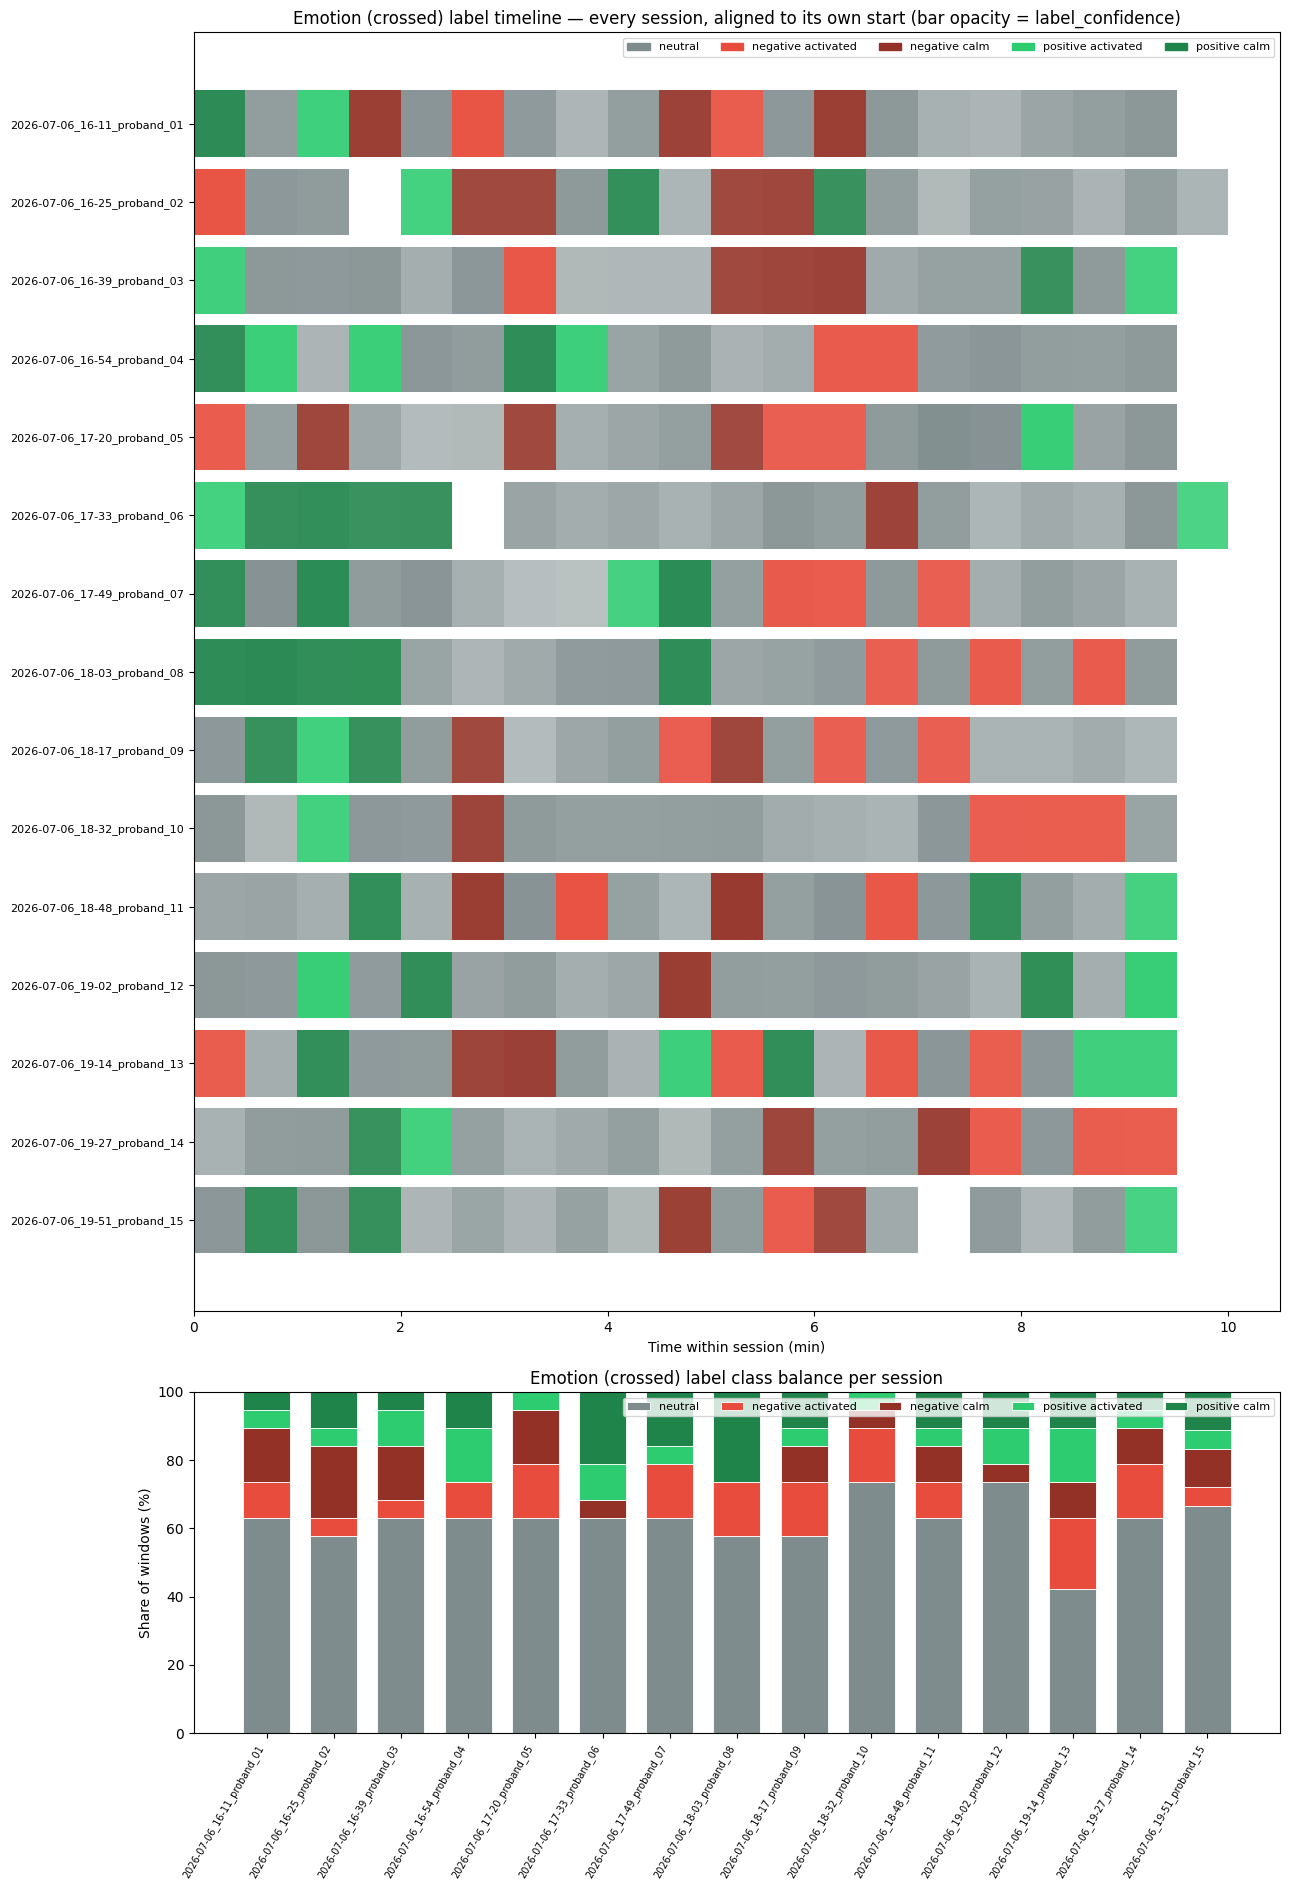

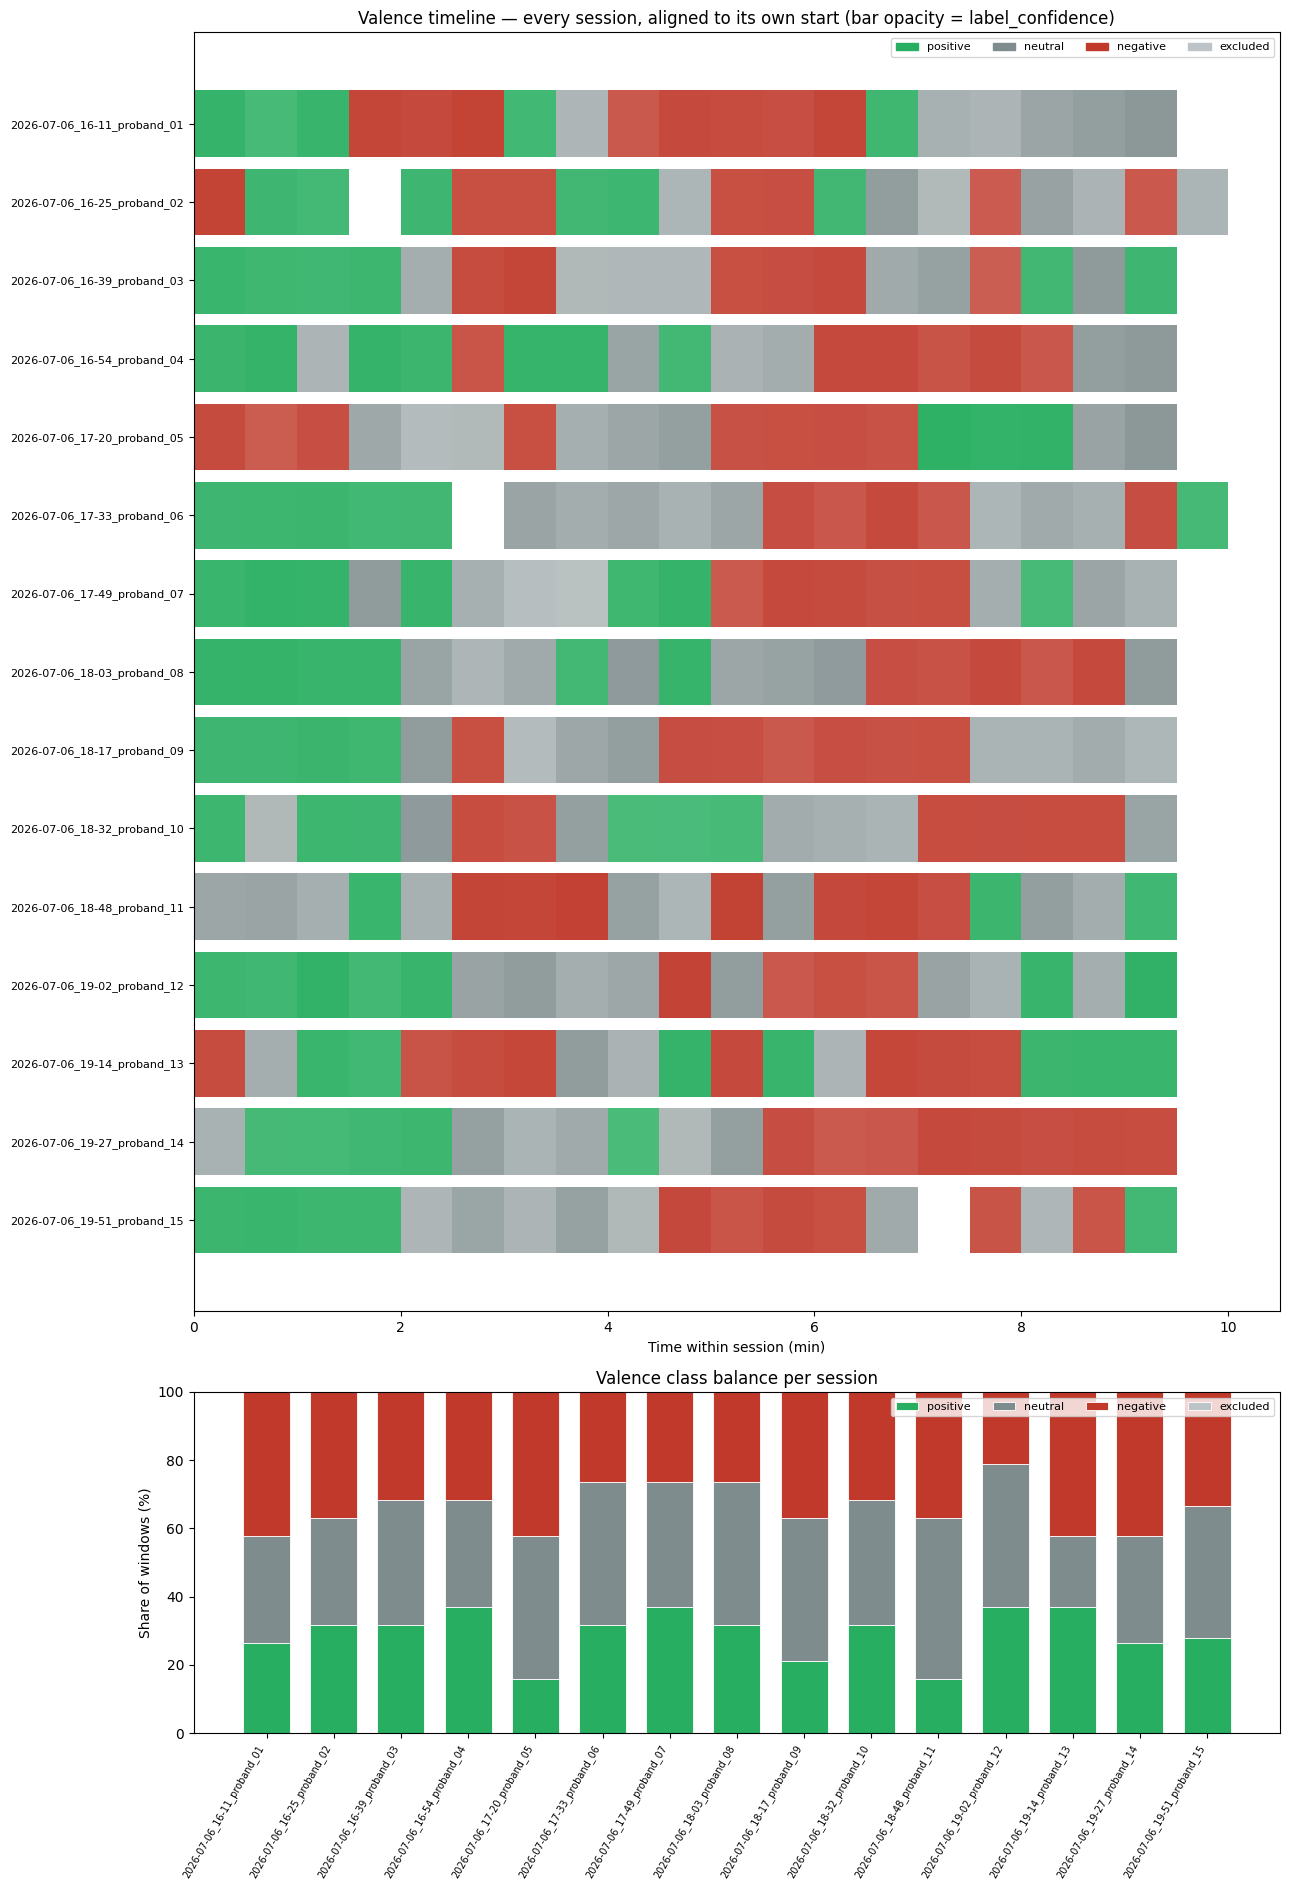

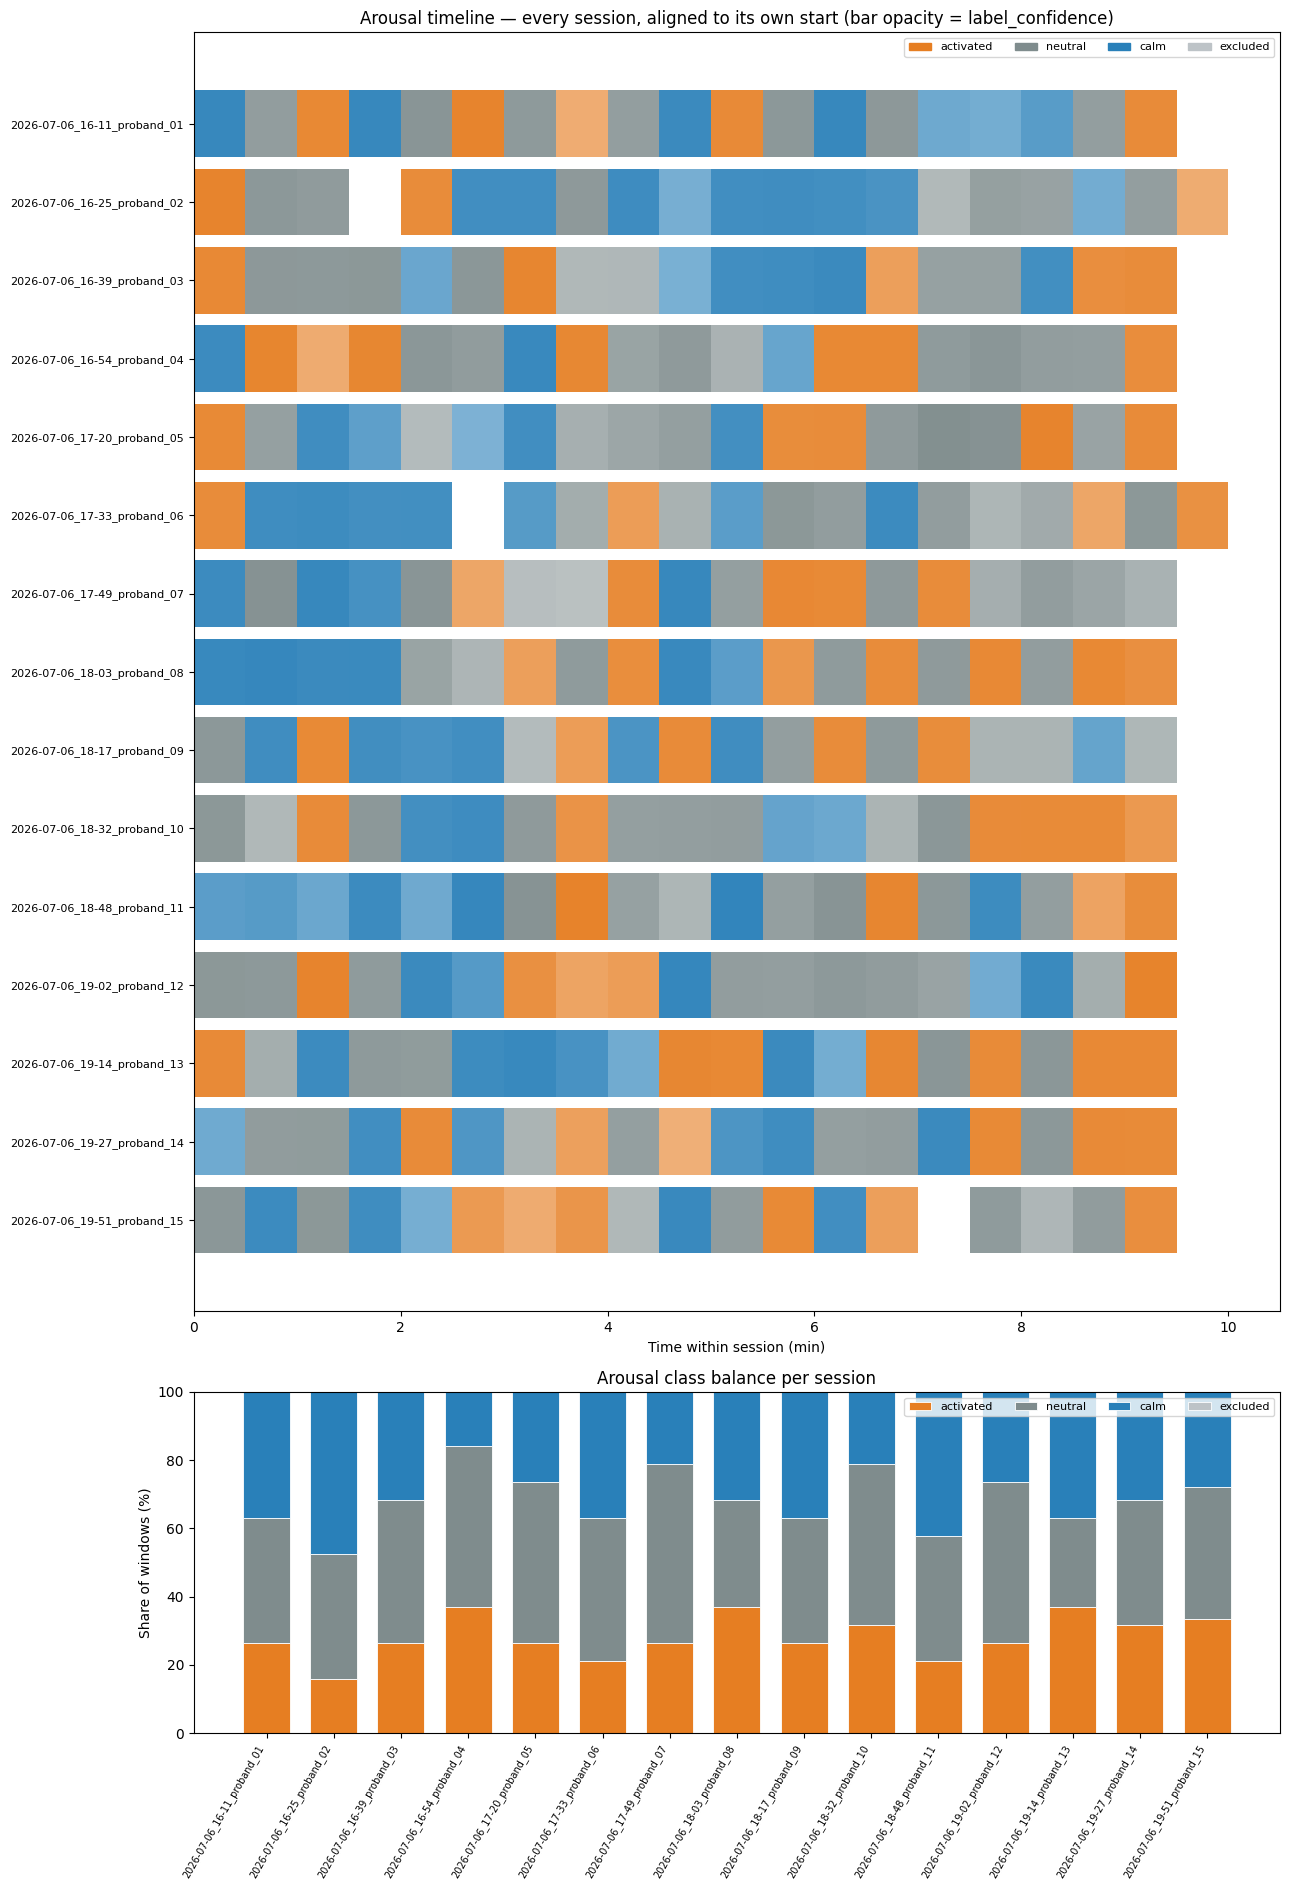

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Fixed categorical colors — same convention used throughout this project
# (see 02_emotion_labelling.ipynb §4.13's valence_col / arousal_col / label_col),
# so the same color always means the same label in every notebook.
VALENCE_COLOR = {"positive": "#27ae60", "neutral": "#7f8c8d",
                 "negative": "#c0392b", "excluded": "#bdc3c7"}
VALENCE_ORDER = ["positive", "neutral", "negative", "excluded"]

AROUSAL_COLOR = {"activated": "#e67e22", "neutral": "#7f8c8d",
                 "calm": "#2980b9", "excluded": "#bdc3c7"}
AROUSAL_ORDER = ["activated", "neutral", "calm", "excluded"]

def _emotion_color(valence, arousal):
    if valence == "excluded" or arousal == "excluded":
        return "#bdc3c7"
    if valence == "neutral" or arousal == "neutral":
        return "#7f8c8d"
    return {
        ("positive", "activated"): "#2ecc71", ("positive", "calm"): "#1e8449",
        ("negative", "activated"): "#e74c3c", ("negative", "calm"): "#943126",
    }[(valence, arousal)]

# `label` crosses valence_direction x arousal_level, but its exact string
# format is whatever 02_emotion_labelling.ipynb currently emits (e.g. a
# space or a hyphen). Rather than hardcode that format here — which is what
# silently broke this section's colouring before — build the colour map from
# each row's own valence_direction/arousal_level (a small fixed vocabulary),
# keyed by whatever `label` string actually occurs.
_emotion_lookup = (dataset[["label", "valence_direction", "arousal_level"]]
                   .drop_duplicates().set_index("label"))
EMOTION_COLOR = {lab: _emotion_color(row.valence_direction, row.arousal_level)
                 for lab, row in _emotion_lookup.iterrows()}
EMOTION_ORDER = sorted(EMOTION_COLOR, key=lambda l: (l != "neutral", l == "excluded", l))

sess_order = sorted(dataset["session_id"].unique())
n_sess = len(sess_order)


def plot_label_timeline_and_balance(df, col, color_map, order, axis_title):
    '''Timeline (top) + per-session class-balance bars (bottom) for one label column.'''
    fig, (ax_tl, ax_bar) = plt.subplots(
        2, 1, figsize=(13, 1.0 * n_sess + 4), gridspec_kw={"height_ratios": [n_sess, 4]}
    )

    # -- Top: multi-row timeline -----------------------------------------
    for row_i, sid in enumerate(sess_order):
        sub = df[df["session_id"] == sid].sort_values("win_start_ms")
        t0 = sub["win_start_ms"].min()
        for _, r in sub.iterrows():
            t_start_min = (r["win_start_ms"] - t0) / 60_000
            conf = r["label_confidence"] if pd.notna(r["label_confidence"]) else 0.0
            # Actual window width from this row's own bounds, not a hardcoded
            # constant - stays correct even if WIN_S changes between sessions.
            width_min = (r["win_end_ms"] - r["win_start_ms"]) / 60_000
            ax_tl.barh(row_i, width_min, left=t_start_min, height=0.85,
                       color=color_map.get(r[col], "#bdc3c7"),
                       alpha=0.3 + 0.7 * conf, edgecolor="none")

    ax_tl.set_yticks(range(n_sess))
    ax_tl.set_yticklabels(sess_order, fontsize=8)
    ax_tl.set_xlabel("Time within session (min)")
    ax_tl.set_title(f"{axis_title} timeline — every session, aligned to its own start "
                    "(bar opacity = label_confidence)")
    ax_tl.invert_yaxis()
    patches = [mpatches.Patch(color=color_map[l], label=l) for l in order if l in color_map]
    ax_tl.legend(handles=patches, loc="upper right", fontsize=8, ncol=len(patches))

    # -- Bottom: per-session class-balance stacked bars -------------------
    counts = (df.groupby(["session_id", col]).size()
              .unstack(fill_value=0).reindex(index=sess_order, columns=order, fill_value=0))
    props = counts.div(counts.sum(axis=1), axis=0) * 100

    bottom = np.zeros(n_sess)
    x = np.arange(n_sess)
    for lab in order:
        if lab not in props.columns:
            continue
        ax_bar.bar(x, props[lab].values, bottom=bottom, color=color_map[lab],
                  label=lab, width=0.7, edgecolor="white", linewidth=0.6)
        bottom += props[lab].values

    ax_bar.set_xticks(x)
    ax_bar.set_xticklabels(sess_order, rotation=60, ha="right", fontsize=7)
    ax_bar.set_ylabel("Share of windows (%)")
    ax_bar.set_title(f"{axis_title} class balance per session")
    ax_bar.set_ylim(0, 100)
    ax_bar.legend(loc="upper right", fontsize=8, ncol=len(patches))

    plt.tight_layout()
    plt.show()


plot_label_timeline_and_balance(dataset, "label", EMOTION_COLOR, EMOTION_ORDER,
                                "Emotion (crossed) label")
plot_label_timeline_and_balance(dataset, "valence_direction", VALENCE_COLOR, VALENCE_ORDER,
                                "Valence")
plot_label_timeline_and_balance(dataset, "arousal_level", AROUSAL_COLOR, AROUSAL_ORDER,
                                "Arousal")


## 10  All Sessions' Other Variables, Side by Side

Section 9 compared the *label* across sessions. `02_emotion_labelling.ipynb`'s
own final visualisation (its Section 4.13) shows five other per-window
signals for a single session: RMSSD, heart rate, FER valence, FER arousal,
and plant voltage - plus `label_confidence`, which drives that plot's bar
opacity. This section is the cross-session equivalent: the same six
variables, one panel each, shown as a heatmap with one row per session.

Sessions run for different lengths and start at different times, so each
session's own window timestamps are rescaled to "percent through this
session" (0-100%) before comparing - otherwise a 9-minute and an 11-minute
session wouldn't line up at all. Colour encodes the variable's value,
independently scaled per panel (5th-95th percentile, so a single outlier
window can't wash out the rest of the panel).

CO2 is not shown here - it was only ever used for the single-session
plot in `02_emotion_labelling.ipynb` §4.13 and was never added to the
per-window ML export (see that notebook's §4.12), so it isn't in
`consolidated_dataset.csv` to plot.


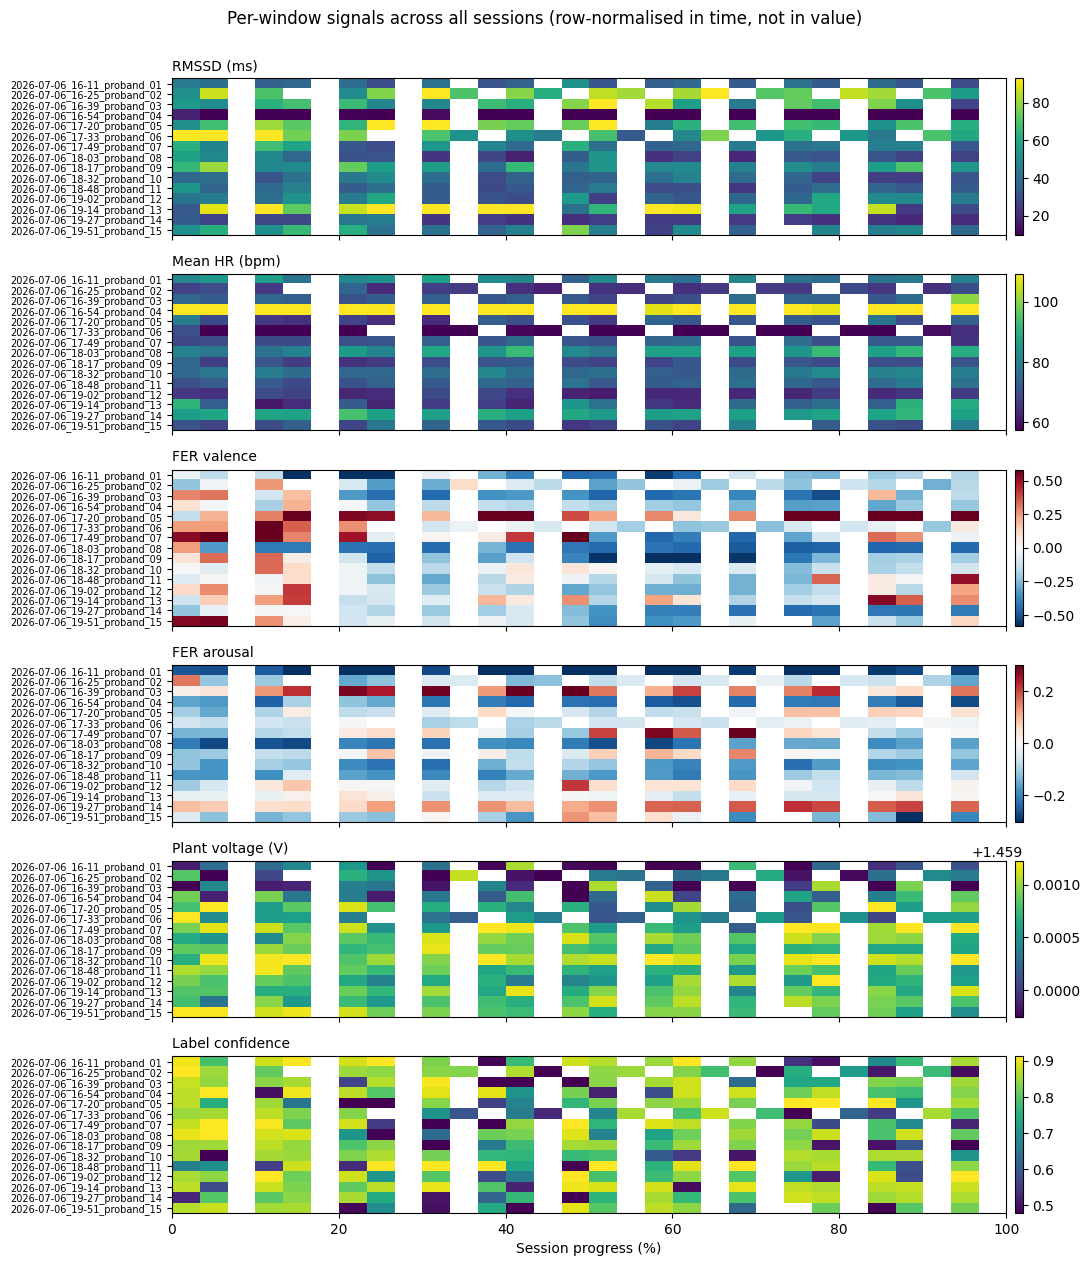

In [22]:
HEATMAP_VARS = [
    ("rmssd",            "RMSSD (ms)",        "viridis", False),
    ("mean_hr",           "Mean HR (bpm)",      "viridis", False),
    ("fer_valence",       "FER valence",        "RdBu_r",  True),
    ("fer_arousal",       "FER arousal",        "RdBu_r",  True),
    ("plant_mean",        "Plant voltage (V)",  "viridis", False),
    ("label_confidence",  "Label confidence",   "viridis", False),
]
N_BINS = 30

def session_heatmap(df, col, sess_order, n_bins=N_BINS):
    grid = np.full((len(sess_order), n_bins), np.nan)
    for row_i, sid in enumerate(sess_order):
        sub = df[df["session_id"] == sid].sort_values("win_start_ms")
        if sub.empty or col not in sub.columns:
            continue
        t0, t1 = sub["win_start_ms"].min(), sub["win_end_ms"].max()
        span = max(1, t1 - t0)
        frac = (sub["win_start_ms"] - t0) / span
        bin_idx = np.clip((frac.to_numpy() * n_bins).astype(int), 0, n_bins - 1)
        vals = pd.to_numeric(sub[col], errors="coerce").to_numpy()
        for b in range(n_bins):
            m = (bin_idx == b) & ~np.isnan(vals)
            if m.any():
                grid[row_i, b] = vals[m].mean()
    return grid


fig, axes = plt.subplots(len(HEATMAP_VARS), 1, figsize=(11, 2.1 * len(HEATMAP_VARS)), sharex=True)
for ax, (col, title, cmap, center0) in zip(np.atleast_1d(axes), HEATMAP_VARS):
    if col not in dataset.columns:
        ax.set_visible(False)
        continue
    grid = session_heatmap(dataset, col, sess_order)
    finite = grid[np.isfinite(grid)]
    if finite.size == 0:
        ax.text(0.5, 0.5, f"no data for {col}", transform=ax.transAxes, ha="center")
        ax.set_yticks([]); continue
    if center0:
        vmax = float(np.nanpercentile(np.abs(finite), 95)) or 1.0
        vmin = -vmax
    else:
        vmin = float(np.nanpercentile(finite, 5))
        vmax = float(np.nanpercentile(finite, 95))
        if vmin == vmax:
            vmax = vmin + 1.0
    im = ax.imshow(grid, aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax,
                   extent=[0, 100, len(sess_order) - 0.5, -0.5], interpolation="nearest")
    ax.set_yticks(range(len(sess_order)))
    ax.set_yticklabels(sess_order, fontsize=7)
    ax.set_title(title, fontsize=10, loc="left")
    fig.colorbar(im, ax=ax, fraction=0.025, pad=0.01)

axes[-1].set_xlabel("Session progress (%)")
fig.suptitle("Per-window signals across all sessions (row-normalised in time, not in value)", y=1.001)
plt.tight_layout()
plt.show()


### Russell circumplex, one panel per session

The same FER valence/arousal scatter `02_emotion_labelling.ipynb` draws for
one session (§4.13, citing Russell, 1980), laid out as small multiples so
sessions can be compared directly instead of only being visible one at a
time.


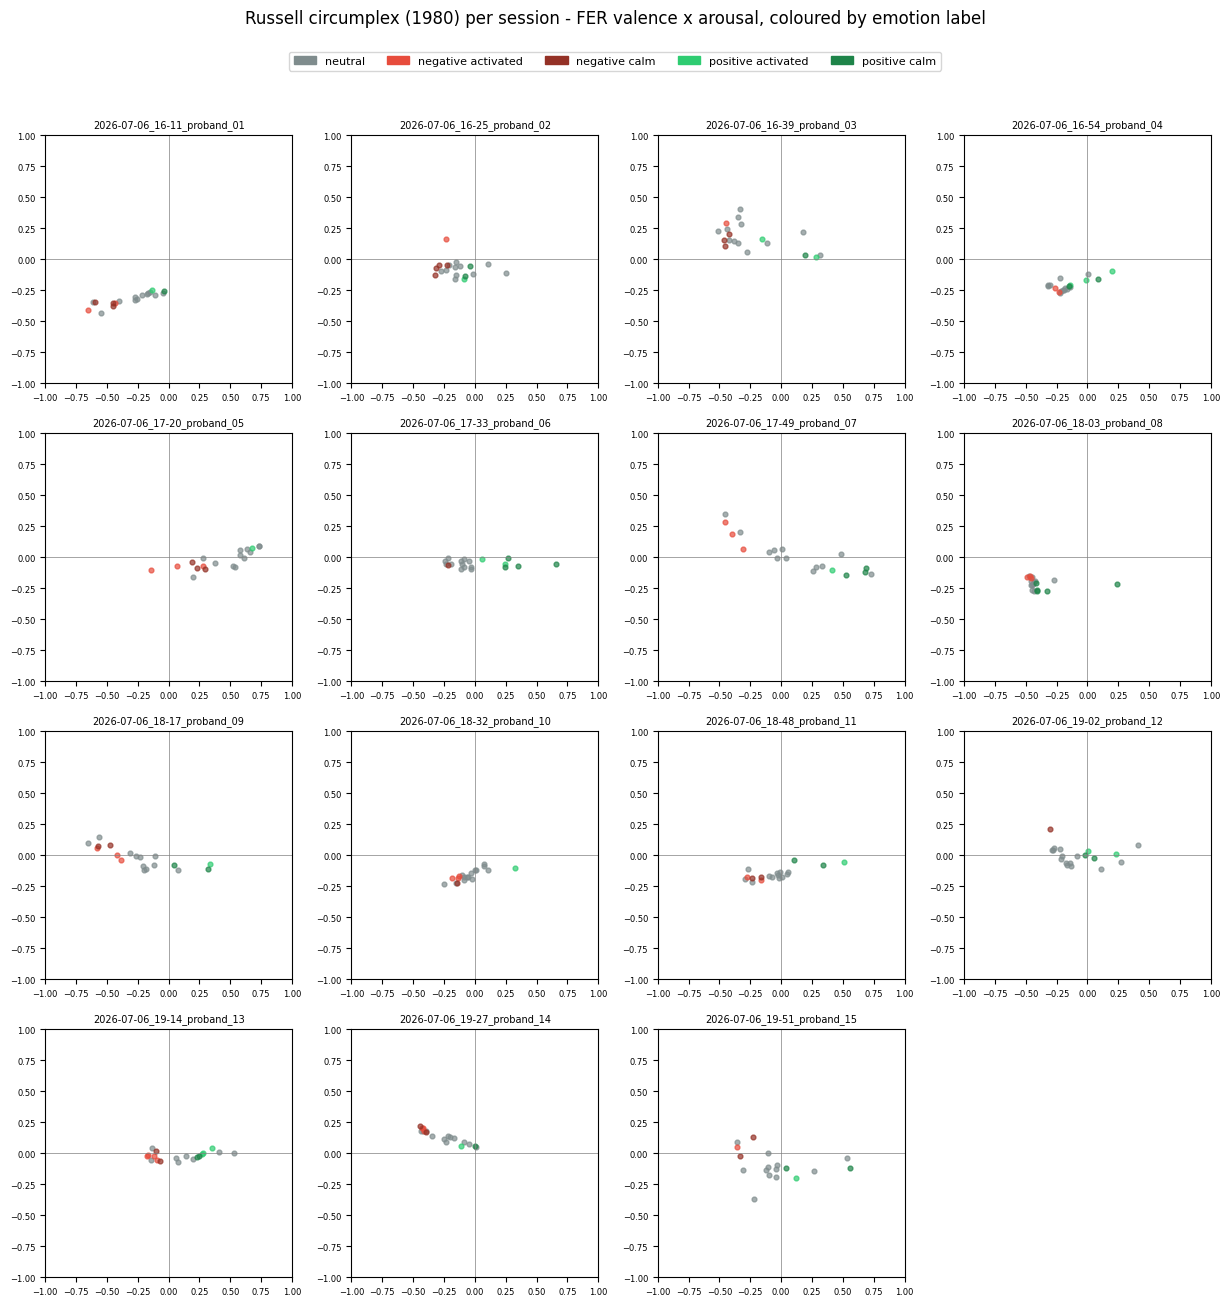

In [23]:
_n = len(sess_order)
_ncols = min(4, _n) or 1
_nrows = int(np.ceil(_n / _ncols))
fig, axes = plt.subplots(_nrows, _ncols, figsize=(3.1 * _ncols, 3.1 * _nrows), squeeze=False)
for i, sid in enumerate(sess_order):
    ax = axes[i // _ncols][i % _ncols]
    sub = dataset[dataset["session_id"] == sid]
    for lab in EMOTION_ORDER:
        s = sub[sub["label"] == lab]
        if len(s):
            ax.scatter(s["fer_valence"], s["fer_arousal"], color=EMOTION_COLOR[lab], s=12, alpha=0.7, label=lab)
    ax.axhline(0, color="gray", lw=0.5); ax.axvline(0, color="gray", lw=0.5)
    ax.set_xlim(-1, 1); ax.set_ylim(-1, 1)
    ax.set_title(sid, fontsize=7)
    ax.tick_params(labelsize=6)
for j in range(_n, _nrows * _ncols):
    axes[j // _ncols][j % _ncols].set_visible(False)
handles = [mpatches.Patch(color=EMOTION_COLOR[l], label=l) for l in EMOTION_ORDER]
fig.legend(handles=handles, loc="upper center", ncol=len(handles), fontsize=8, bbox_to_anchor=(0.5, 1.02))
fig.suptitle("Russell circumplex (1980) per session - FER valence x arousal, coloured by emotion label", y=1.05)
plt.tight_layout()
plt.show()


### Label confidence, side by side

`label_confidence` sets the label timeline's bar opacity in both this
notebook (Section 9) and `02_emotion_labelling.ipynb` §4.13. Here it is
shown directly, one distribution per session, so you can see whether some
sessions are systematically less confident than others rather than only
inferring it from bar opacity.


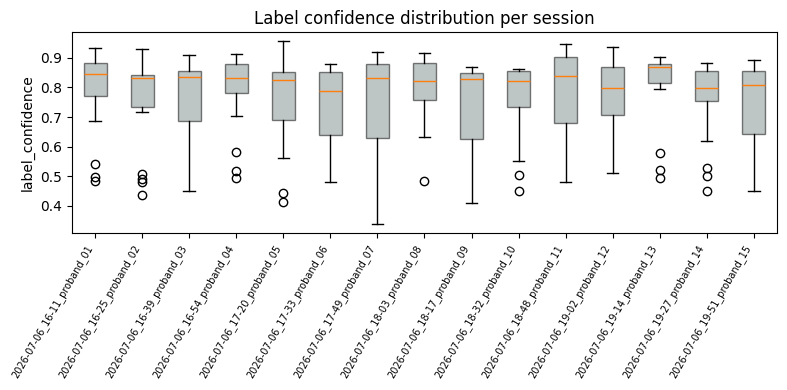

In [24]:
_by_sess = [dataset.loc[dataset.session_id == sid, "label_confidence"].dropna().to_numpy()
           for sid in sess_order]
fig, ax = plt.subplots(figsize=(max(8, 0.5 * len(sess_order)), 4))
bp = ax.boxplot(_by_sess, tick_labels=sess_order, showfliers=True, patch_artist=True)
for patch in bp["boxes"]:
    patch.set_facecolor("#7f8c8d"); patch.set_alpha(0.5)
ax.set_xticklabels(sess_order, rotation=60, ha="right", fontsize=7)
ax.set_ylabel("label_confidence")
ax.set_title("Label confidence distribution per session")
plt.tight_layout()
plt.show()


---

**Next step:** open **Notebook 2 — Machine Learning Pipeline**, which loads
`consolidated_dataset.csv` and trains and compares three classifiers.
